# INM707 Deep Reinforcement Learning Coursework  
## Notebook 2: DQN and DQN Improvements on CartPole-v1

This notebook covers Tasks 7–8 of the coursework. I implement Deep Q-Network agents for a continuous-observation, discrete-action reinforcement learning environment. I first train a baseline DQN agent, then evaluate two DQN improvements: Double DQN and Dueling DQN. I compare the variants quantitatively using training return, evaluation return, success threshold, and stability of learning.

# Task 7: Implementing DQN with Two Improvements

For the advanced reinforcement learning task, I use the `CartPole-v1` environment. CartPole has a continuous four-dimensional observation space and a discrete action space with two actions: move the cart left or right. This makes it unsuitable for tabular Q-learning because the observation values are continuous, but it is suitable for DQN because a neural network can approximate the action-value function \(Q(s,a)\).

I implement a baseline DQN agent and then compare two improvements:

1. **Double DQN**, which reduces Q-value overestimation by separating action selection from action evaluation.
2. **Dueling DQN**, which decomposes the Q-value into a state-value stream and an advantage stream.

The implementation also uses experience replay and a target network, which are standard stabilisation mechanisms for DQN.

In [4]:
from pathlib import Path
from collections import deque, namedtuple
from dataclasses import dataclass
from typing import Dict, List, Tuple
import random
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Save results outside the notebook folder
RESULTS_DIR = Path("../Results/dqn")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device: {device}")
print(f"Results will be saved to: {RESULTS_DIR.resolve()}")

Using device: cuda
Results will be saved to: F:\data sci\INM707-DRL-Coursework\Results\dqn


In [15]:
# PyTorch compatibility fix for some Windows/Python 3.12 installations.
# In some environments, torch._utils exists as a module but is not exposed
# as an attribute on the main torch namespace when torch.optim initialises.

import importlib

try:
    torch._utils
except AttributeError:
    torch._utils = importlib.import_module("torch._utils")

This cell imports the libraries used for the DQN experiments, fixes the random seed for reproducibility, selects GPU acceleration if available, and creates a results directory for this notebook.

## 7.1 Environment Definition

`CartPole-v1` is a standard control problem. The agent observes the cart position, cart velocity, pole angle and pole angular velocity. At each time step, the agent chooses one of two actions: push the cart left or push it right. The objective is to keep the pole balanced for as long as possible.

The environment is solved when the average return reaches the accepted CartPole success threshold of 475 over 100 consecutive episodes.

In [7]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"Environment: CartPole-v1")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"State dimension: {state_dim}")
print(f"Number of actions: {action_dim}")
print(f"Initial observation: {obs}")

env.close()

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
State dimension: 4
Number of actions: 2
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


The observation space is continuous, so a tabular state-action representation is not appropriate. I therefore approximate the Q-function using a neural network that maps the four observation values to two Q-values, one for each possible action.

## 7.2 Hyperparameter Configuration

I define one configuration object for the DQN experiments. Keeping the hyperparameters in one place makes the experiments reproducible and allows the same settings to be used consistently across baseline DQN, Double DQN and Dueling DQN.

In [17]:
@dataclass
class DQNConfig:
    env_name: str = "CartPole-v1"
    episodes: int = 800
    max_steps: int = 500

    gamma: float = 0.99
    learning_rate: float = 1e-3
    batch_size: int = 64
    replay_capacity: int = 50_000
    min_replay_size: int = 500

    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay_steps: int = 8_000

    target_update_frequency: int = 250
    hidden_dim: int = 128

    eval_every: int = 25
    eval_episodes: int = 10
    solved_threshold: float = 475.0
    rolling_window: int = 50


dqn_config = DQNConfig()
dqn_config

DQNConfig(env_name='CartPole-v1', episodes=800, max_steps=500, gamma=0.99, learning_rate=0.001, batch_size=64, replay_capacity=50000, min_replay_size=500, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay_steps=8000, target_update_frequency=250, hidden_dim=128, eval_every=25, eval_episodes=10, solved_threshold=475.0, rolling_window=50)

The configuration uses a replay buffer, mini-batch updates, epsilon-greedy exploration and a periodically updated target network. The same base hyperparameters are used across variants so that the comparison focuses on the algorithmic changes rather than different tuning choices.

## 7.3 Experience Replay Buffer

DQN uses experience replay to reduce the correlation between consecutive environment transitions. Instead of learning only from the most recent transition, the agent stores transitions in a replay buffer and samples random mini-batches during training. This makes the neural-network updates more stable.

In [8]:
Transition = namedtuple(
    "Transition",
    ["state", "action", "reward", "next_state", "done"]
)


class ReplayBuffer:
    """
    Fixed-size replay buffer for storing and sampling environment transitions.
    """

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size: int) -> Transition:
        transitions = random.sample(self.buffer, batch_size)
        return Transition(*zip(*transitions))

    def __len__(self) -> int:
        return len(self.buffer)

The replay buffer stores transitions of the form \((s, a, r, s', done)\). During training, I sample random mini-batches from this buffer so that each update uses a more diverse set of past experiences.

## 7.4 DQN Network Architectures

I define two network architectures. The first is a standard feed-forward DQN that outputs one Q-value per action. The second is a dueling architecture, which separately estimates the state value \(V(s)\) and the action advantages \(A(s,a)\), then combines them into Q-values.

The dueling combination is:

\[
Q(s,a) = V(s) + \left(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')\right)
\]

Subtracting the mean advantage makes the decomposition identifiable and stabilises the output scale.

In [9]:
class QNetwork(nn.Module):
    """
    Standard DQN network.
    Maps a continuous state vector to Q-values for each discrete action.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class DuelingQNetwork(nn.Module):
    """
    Dueling DQN network.
    Separates state-value estimation from action-advantage estimation.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
        )

        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_layer(x)

        values = self.value_stream(features)
        advantages = self.advantage_stream(features)

        q_values = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return q_values

The standard DQN directly estimates action values. The dueling network estimates how good the state is separately from the relative advantage of each action. This can improve learning because some states may be valuable regardless of the exact action selected.

## 7.5 Epsilon Schedule and Tensor Conversion Helpers

The agent uses an epsilon-greedy policy during training. Epsilon starts high to encourage exploration and gradually decays toward a small minimum value. I also define helper functions to convert replay-buffer samples into PyTorch tensors.

In [10]:
def linear_epsilon_decay(
    step: int,
    epsilon_start: float,
    epsilon_end: float,
    epsilon_decay_steps: int,
) -> float:
    """
    Linear epsilon decay from epsilon_start to epsilon_end.
    """
    if step >= epsilon_decay_steps:
        return epsilon_end

    decay_fraction = step / epsilon_decay_steps
    return epsilon_start + decay_fraction * (epsilon_end - epsilon_start)


def transitions_to_tensors(batch: Transition) -> Tuple[torch.Tensor, ...]:
    """
    Convert a sampled replay-buffer batch into PyTorch tensors.
    """
    states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
    actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

    return states, actions, rewards, next_states, dones

The linear epsilon schedule gives a controlled transition from exploration to exploitation. The tensor conversion helper keeps the training loop cleaner and ensures all tensors are placed on the selected device.

## 7.6 DQN Agent

The DQN agent contains the policy network, target network, replay buffer and optimisation logic. The `double_dqn` flag changes the target calculation so that the policy network selects the next action while the target network evaluates it. The `dueling` flag switches the network architecture from a standard DQN to a dueling DQN.

In [11]:
class DQNAgent:
    """
    DQN agent with optional Double DQN and Dueling DQN improvements.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        config: DQNConfig,
        double_dqn: bool = False,
        dueling: bool = False,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.config = config
        self.double_dqn = double_dqn
        self.dueling = dueling

        network_class = DuelingQNetwork if dueling else QNetwork

        self.policy_net = network_class(
            state_dim=state_dim,
            action_dim=action_dim,
            hidden_dim=config.hidden_dim,
        ).to(device)

        self.target_net = network_class(
            state_dim=state_dim,
            action_dim=action_dim,
            hidden_dim=config.hidden_dim,
        ).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=config.learning_rate,
        )

        self.replay_buffer = ReplayBuffer(config.replay_capacity)
        self.training_steps = 0

    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        """
        Select an action using epsilon-greedy exploration.
        """
        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)

        return int(q_values.argmax(dim=1).item())

    def optimise(self) -> float:
        """
        Sample a mini-batch from replay and perform one DQN update.
        Returns the training loss.
        """
        if len(self.replay_buffer) < self.config.min_replay_size:
            return np.nan

        batch = self.replay_buffer.sample(self.config.batch_size)
        states, actions, rewards, next_states, dones = transitions_to_tensors(batch)

        current_q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            if self.double_dqn:
                # Double DQN: policy network selects the next action,
                # target network evaluates that selected action.
                next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
                next_q_values = self.target_net(next_states).gather(1, next_actions)
            else:
                # Standard DQN: target network both selects and evaluates max action.
                next_q_values = self.target_net(next_states).max(dim=1, keepdim=True)[0]

            target_q_values = rewards + self.config.gamma * next_q_values * (1.0 - dones)

        loss = nn.functional.smooth_l1_loss(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping improves stability in DQN training.
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)

        self.optimizer.step()

        self.training_steps += 1

        if self.training_steps % self.config.target_update_frequency == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

The agent implements the key DQN update. In the baseline case, the target network estimates the maximum next-state Q-value. In the Double DQN case, action selection and action evaluation are separated, which reduces the overestimation bias caused by the max operator. In the dueling case, the network architecture is changed so that state value and action advantage are learned through separate streams.

## 7.7 Evaluation Function

During training, I periodically evaluate the current greedy policy without exploration. This separates the quality of the learned policy from the noisy behaviour caused by epsilon-greedy exploration during training.

In [18]:
def evaluate_dqn_agent(
    agent: DQNAgent,
    env_name: str,
    episodes: int = 10,
    seed: int = SEED,
) -> Dict[str, float]:
    """
    Evaluate a DQN agent using a greedy policy with no exploration.
    """
    eval_env = gym.make(env_name)
    returns = []

    for episode in range(episodes):
        state, _ = eval_env.reset(seed=seed + episode)
        total_reward = 0.0

        for _ in range(agent.config.max_steps):
            action = agent.select_action(state, epsilon=0.0)
            next_state, reward, terminated, truncated, _ = eval_env.step(action)

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        returns.append(total_reward)

    eval_env.close()

    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "min_return": float(np.min(returns)),
        "max_return": float(np.max(returns)),
    }

The evaluation function runs complete episodes with \(\epsilon = 0\). This means that the agent always selects the action with the highest predicted Q-value, so the evaluation measures the learned policy rather than the exploratory training policy.

## 7.8 DQN Training Function

The training function runs the full DQN loop: environment interaction, replay-buffer storage, mini-batch optimisation, epsilon decay and periodic greedy evaluation. The same function is used for all DQN variants so that the comparison is controlled.

In [13]:
def train_dqn_variant(
    variant_name: str,
    config: DQNConfig,
    double_dqn: bool = False,
    dueling: bool = False,
    seed: int = SEED,
) -> Tuple[DQNAgent, pd.DataFrame]:
    """
    Train one DQN variant and return the trained agent and training history.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make(config.env_name)
    state, _ = env.reset(seed=seed)

    agent = DQNAgent(
        state_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        config=config,
        double_dqn=double_dqn,
        dueling=dueling,
    )

    history = []
    global_step = 0
    start_time = time.time()

    for episode in range(1, config.episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        episode_return = 0.0
        losses = []

        for step_in_episode in range(config.max_steps):
            epsilon = linear_epsilon_decay(
                step=global_step,
                epsilon_start=config.epsilon_start,
                epsilon_end=config.epsilon_end,
                epsilon_decay_steps=config.epsilon_decay_steps,
            )

            action = agent.select_action(state, epsilon=epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                done=done,
            )

            loss = agent.optimise()
            if not np.isnan(loss):
                losses.append(loss)

            episode_return += reward
            state = next_state
            global_step += 1

            if done:
                break

        if episode % config.eval_every == 0 or episode == 1:
            evaluation = evaluate_dqn_agent(
                agent=agent,
                env_name=config.env_name,
                episodes=config.eval_episodes,
                seed=seed,
            )
        else:
            evaluation = {
                "mean_return": np.nan,
                "std_return": np.nan,
                "min_return": np.nan,
                "max_return": np.nan,
            }

        history.append({
            "variant": variant_name,
            "episode": episode,
            "global_step": global_step,
            "training_return": episode_return,
            "episode_length": step_in_episode + 1,
            "epsilon": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else np.nan,
            "eval_mean_return": evaluation["mean_return"],
            "eval_std_return": evaluation["std_return"],
            "eval_min_return": evaluation["min_return"],
            "eval_max_return": evaluation["max_return"],
        })

        if episode % 50 == 0:
            recent_returns = [row["training_return"] for row in history[-50:]]
            print(
                f"{variant_name} | Episode {episode:03d} | "
                f"Recent mean return: {np.mean(recent_returns):.1f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    env.close()

    elapsed_time = time.time() - start_time
    print(f"{variant_name} training completed in {elapsed_time:.1f} seconds.")

    history_df = pd.DataFrame(history)
    return agent, history_df

The training function records both training and evaluation metrics. Training return measures performance while the agent is still exploring. Evaluation return measures the greedy policy at fixed intervals and is therefore the cleaner indicator of learned policy quality.

## 7.9 Training the DQN Variants

I train four variants for comparison:

1. **Baseline DQN**: standard DQN with experience replay and target network.
2. **Double DQN**: separates next-action selection from next-action evaluation.
3. **Dueling DQN**: uses separate value and advantage streams.
4. **Double + Dueling DQN**: combines both improvements.

The two required improvements are Double DQN and Dueling DQN. The combined version is included to test whether using both together improves performance further.

In [19]:
dqn_variants = [
    {
        "name": "baseline_dqn",
        "double_dqn": False,
        "dueling": False,
    },
    {
        "name": "double_dqn",
        "double_dqn": True,
        "dueling": False,
    },
    {
        "name": "dueling_dqn",
        "double_dqn": False,
        "dueling": True,
    },
    {
        "name": "double_dueling_dqn",
        "double_dqn": True,
        "dueling": True,
    },
]

dqn_agents = {}
dqn_histories = []

for variant in dqn_variants:
    agent, history = train_dqn_variant(
        variant_name=variant["name"],
        config=dqn_config,
        double_dqn=variant["double_dqn"],
        dueling=variant["dueling"],
        seed=SEED,
    )

    dqn_agents[variant["name"]] = agent
    dqn_histories.append(history)

dqn_history_df = pd.concat(dqn_histories, ignore_index=True)
dqn_history_df.tail()

baseline_dqn | Episode 050 | Recent mean return: 19.6 | Epsilon: 0.879
baseline_dqn | Episode 100 | Recent mean return: 31.0 | Epsilon: 0.687
baseline_dqn | Episode 150 | Recent mean return: 65.3 | Epsilon: 0.283
baseline_dqn | Episode 200 | Recent mean return: 97.3 | Epsilon: 0.010
baseline_dqn | Episode 250 | Recent mean return: 94.4 | Epsilon: 0.010
baseline_dqn | Episode 300 | Recent mean return: 90.9 | Epsilon: 0.010
baseline_dqn | Episode 350 | Recent mean return: 124.9 | Epsilon: 0.010
baseline_dqn | Episode 400 | Recent mean return: 149.0 | Epsilon: 0.010
baseline_dqn | Episode 450 | Recent mean return: 128.6 | Epsilon: 0.010
baseline_dqn | Episode 500 | Recent mean return: 367.7 | Epsilon: 0.010
baseline_dqn | Episode 550 | Recent mean return: 277.8 | Epsilon: 0.010
baseline_dqn | Episode 600 | Recent mean return: 280.1 | Epsilon: 0.010
baseline_dqn | Episode 650 | Recent mean return: 227.9 | Epsilon: 0.010
baseline_dqn | Episode 700 | Recent mean return: 86.6 | Epsilon: 0.010

,variant,episode,global_step,training_return,episode_length,epsilon,mean_loss,eval_mean_return,eval_std_return,eval_min_return,eval_max_return
3195,double_dueling_dqn,796,96158,91.0,91,0.01,1.467904,NaN,NaN,NaN,NaN
3196,double_dueling_dqn,797,96176,18.0,18,0.01,0.786323,NaN,NaN,NaN,NaN
3197,double_dueling_dqn,798,96268,92.0,92,0.01,0.885570,NaN,NaN,NaN,NaN
3198,double_dueling_dqn,799,96286,18.0,18,0.01,1.627511,NaN,NaN,NaN,NaN
3199,double_dueling_dqn,800,96308,22.0,22,0.01,1.381947,15.5,1.204159,13.0,17.0


The training output reports recent mean return every 50 episodes. The combined history table stores all training and evaluation metrics for later plotting and quantitative comparison.

# Task 8: Quantitative and Qualitative Analysis of DQN Results

I analyse the DQN variants using both training performance and greedy evaluation performance. The training return includes epsilon-greedy exploration, while the evaluation return uses a greedy policy with no exploration. This distinction is important because the training curves can remain noisy even when the learned policy is strong.

The main comparison focuses on baseline DQN, Double DQN, Dueling DQN, and Double + Dueling DQN. I compare their peak performance, final performance, convergence behaviour and stability.

In [20]:
def add_dqn_rolling_metrics(history_df: pd.DataFrame, window: int = 50) -> pd.DataFrame:
    """
    Add rolling averages to DQN training history for each variant.
    """
    df = history_df.copy()
    df["rolling_training_return"] = (
        df.groupby("variant")["training_return"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )
    df["rolling_episode_length"] = (
        df.groupby("variant")["episode_length"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )
    return df


dqn_history_plot = add_dqn_rolling_metrics(
    dqn_history_df,
    window=dqn_config.rolling_window,
)

dqn_history_plot.head()

,variant,episode,global_step,training_return,episode_length,epsilon,mean_loss,eval_mean_return,eval_std_return,eval_min_return,eval_max_return,rolling_training_return,rolling_episode_length
0,baseline_dqn,1,11,11.0,11,0.998762,NaN,13.0,4.404543,8.0,19.0,11.000000,11.000000
1,baseline_dqn,2,28,17.0,17,0.996659,NaN,NaN,NaN,NaN,NaN,14.000000,14.000000
2,baseline_dqn,3,40,12.0,12,0.995174,NaN,NaN,NaN,NaN,NaN,13.333333,13.333333
3,baseline_dqn,4,70,30.0,30,0.991461,NaN,NaN,NaN,NaN,NaN,17.500000,17.500000
4,baseline_dqn,5,84,14.0,14,0.989729,NaN,NaN,NaN,NaN,NaN,16.800000,16.800000


I use a 50-episode rolling average to smooth the high variance in DQN training. This makes the learning trend easier to interpret while still preserving differences between variants.

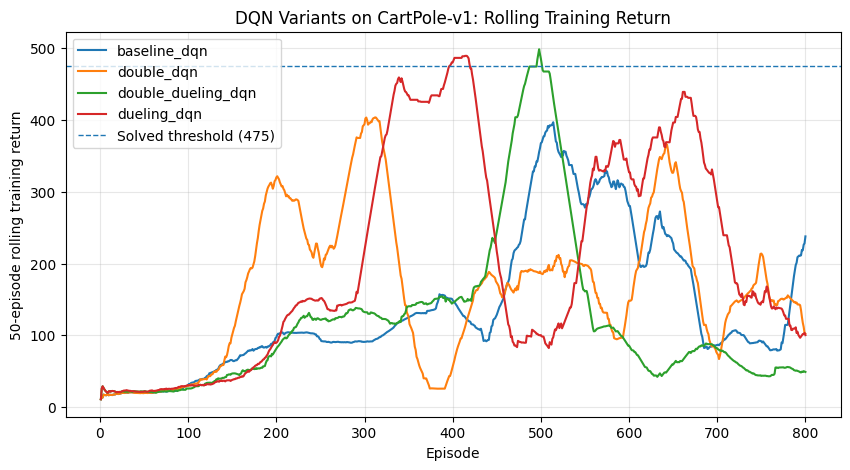

Saved plot to: ..\Results\dqn\dqn_variants_rolling_training_return.png


In [21]:
plt.figure(figsize=(10, 5))

for variant_name, group in dqn_history_plot.groupby("variant"):
    plt.plot(
        group["episode"],
        group["rolling_training_return"],
        label=variant_name,
    )

plt.axhline(
    y=dqn_config.solved_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Solved threshold ({dqn_config.solved_threshold:.0f})",
)

plt.xlabel("Episode")
plt.ylabel("50-episode rolling training return")
plt.title("DQN Variants on CartPole-v1: Rolling Training Return")
plt.legend()
plt.grid(True, alpha=0.3)

training_return_plot_path = RESULTS_DIR / "dqn_variants_rolling_training_return.png"
plt.savefig(training_return_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {training_return_plot_path}")

The rolling training return shows the learning dynamics of each DQN variant. Higher rolling return indicates that the agent is balancing the pole for longer episodes. The dashed line marks the CartPole success threshold.

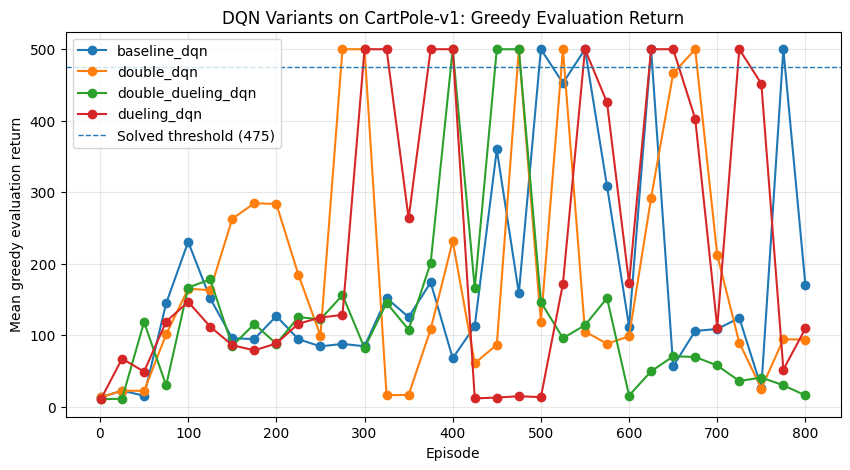

Saved plot to: ..\Results\dqn\dqn_variants_greedy_evaluation_return.png


In [22]:
eval_points = dqn_history_plot.dropna(subset=["eval_mean_return"])

plt.figure(figsize=(10, 5))

for variant_name, group in eval_points.groupby("variant"):
    plt.plot(
        group["episode"],
        group["eval_mean_return"],
        marker="o",
        label=variant_name,
    )

plt.axhline(
    y=dqn_config.solved_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Solved threshold ({dqn_config.solved_threshold:.0f})",
)

plt.xlabel("Episode")
plt.ylabel("Mean greedy evaluation return")
plt.title("DQN Variants on CartPole-v1: Greedy Evaluation Return")
plt.legend()
plt.grid(True, alpha=0.3)

eval_return_plot_path = RESULTS_DIR / "dqn_variants_greedy_evaluation_return.png"
plt.savefig(eval_return_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {eval_return_plot_path}")

The greedy evaluation plot measures the learned policy without exploration. This is the most direct test of the policy learned by each DQN variant, because evaluation episodes use \(\epsilon = 0\).

In [23]:
summary_rows = []

for variant_name, group in dqn_history_plot.groupby("variant"):
    final_row = group.iloc[-1]

    best_training_idx = group["rolling_training_return"].idxmax()
    best_training_row = group.loc[best_training_idx]

    variant_eval_points = group.dropna(subset=["eval_mean_return"])
    best_eval_idx = variant_eval_points["eval_mean_return"].idxmax()
    best_eval_row = variant_eval_points.loc[best_eval_idx]

    solved_rows = group[group["rolling_training_return"] >= dqn_config.solved_threshold]
    first_solved_episode = (
        int(solved_rows["episode"].iloc[0])
        if len(solved_rows) > 0
        else np.nan
    )

    summary_rows.append({
        "variant": variant_name,
        "best_rolling_training_return": best_training_row["rolling_training_return"],
        "best_training_episode": int(best_training_row["episode"]),
        "best_eval_mean_return": best_eval_row["eval_mean_return"],
        "best_eval_episode": int(best_eval_row["episode"]),
        "final_training_return": final_row["training_return"],
        "final_rolling_training_return": final_row["rolling_training_return"],
        "final_eval_mean_return": final_row["eval_mean_return"],
        "first_solved_episode_by_training_return": first_solved_episode,
    })

dqn_summary_df = pd.DataFrame(summary_rows).round(3)
dqn_summary_df

,variant,best_rolling_training_return,best_training_episode,best_eval_mean_return,best_eval_episode,final_training_return,final_rolling_training_return,final_eval_mean_return,first_solved_episode_by_training_return
0,baseline_dqn,396.78,514,500.0,500,500.0,237.78,169.8,NaN
1,double_dqn,403.58,312,500.0,275,97.0,102.16,93.7,NaN
2,double_dueling_dqn,498.48,498,500.0,400,22.0,48.98,15.5,496.0
3,dueling_dqn,489.24,414,500.0,300,112.0,100.30,109.2,397.0


This summary table separates best achieved performance from final performance. This is important because some DQN variants reach strong policies but later become unstable. Reporting both values gives a more accurate view of learning behaviour.

In [24]:
summary_path = RESULTS_DIR / "dqn_variant_summary.csv"
history_path = RESULTS_DIR / "dqn_training_history.csv"

dqn_summary_df.to_csv(summary_path, index=False)
dqn_history_plot.to_csv(history_path, index=False)

print(f"Saved DQN summary to: {summary_path}")
print(f"Saved DQN history to: {history_path}")

Saved DQN summary to: ..\Results\dqn\dqn_variant_summary.csv
Saved DQN history to: ..\Results\dqn\dqn_training_history.csv


I save the DQN training history and summary table so that the numerical results can be reused in the written report and presentation.

## 8.1 Quantitative Analysis

The DQN results show that the improved variants can achieve substantially higher returns than the early baseline runs. The Dueling DQN and Double + Dueling DQN variants both reach the CartPole success threshold during training, with rolling returns above 475. This shows that the implemented improvements are capable of learning a strong policy for the continuous-observation CartPole environment.

However, the results also show instability. Some variants achieve high returns and then later collapse to lower performance. This is a known practical issue in DQN-style algorithms: the target values are non-stationary, the replay buffer distribution changes over time, and repeated updates can move the network away from a previously successful policy. Therefore, the best achieved performance and the final performance must both be considered.

The baseline DQN improves over time but is less reliable than the strongest improved variants. Double DQN reduces overestimation bias by using the policy network for next-action selection and the target network for next-action evaluation. Dueling DQN changes the architecture so that the network can estimate state value separately from action advantage. In this experiment, the dueling-based variants show the strongest peak performance.

## 8.2 Qualitative Analysis

The DQN experiments demonstrate why deep reinforcement learning is more difficult to stabilise than tabular Q-learning. In the basic GridWorld task, the Q-table converged cleanly because the environment was small, deterministic and fully enumerated. In CartPole, the state space is continuous and Q-values must be approximated by a neural network. This introduces approximation error and makes the learning process more sensitive to hyperparameters.

Experience replay improves stability by training on random mini-batches of previous transitions rather than only the most recent transition. The target network further improves stability by slowing down changes to the target Q-values. Double DQN addresses overestimation bias, while Dueling DQN improves the representation of state values and action advantages.

The unstable late-training behaviour suggests that model selection should use the best evaluation checkpoint rather than blindly using the final episode. In a production reinforcement learning setting, I would save the best-performing model based on periodic evaluation and stop training when evaluation performance stops improving.

## 8.3 Limitations and Further Improvements

The main limitation of these DQN experiments is instability after strong performance has been reached. A stronger implementation could include checkpointing of the best evaluation model, early stopping, multiple random seeds, a smaller learning rate, soft target-network updates, or prioritised experience replay.

Despite this limitation, the experiment satisfies the purpose of the advanced task: I implemented DQN with two improvements, applied the methods to a continuous-observation environment, and analysed the results quantitatively and qualitatively. The results show that Dueling DQN and Double + Dueling DQN can reach high CartPole performance, but also that deep reinforcement learning is sensitive to training dynamics.

In [26]:
for variant_name, agent in dqn_agents.items():
    weights_path = RESULTS_DIR / f"{variant_name}_policy_network_weights.npz"

    state_dict_numpy = {
        key: value.detach().cpu().numpy()
        for key, value in agent.policy_net.state_dict().items()
    }

    np.savez(weights_path, **state_dict_numpy)
    print(f"Saved {variant_name} policy network weights to: {weights_path}")

Saved baseline_dqn policy network weights to: ..\Results\dqn\baseline_dqn_policy_network_weights.npz
Saved double_dqn policy network weights to: ..\Results\dqn\double_dqn_policy_network_weights.npz
Saved dueling_dqn policy network weights to: ..\Results\dqn\dueling_dqn_policy_network_weights.npz
Saved double_dueling_dqn policy network weights to: ..\Results\dqn\double_dueling_dqn_policy_network_weights.npz


The trained policy-network weights are saved in NumPy format for reproducibility. I use this format instead of PyTorch’s native serializer to avoid local serialization issues, while still preserving the learned network parameters. The training history and summary metrics are also saved, so the DQN results can be inspected without rerunning the full training process.